**CNN-Attention + Tabular Arm**

In [1]:
!pip install antropy nolds

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.7/225.7 kB 5.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
from scipy.signal import butter, lfilter
import antropy as ant
import nolds
import os
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return b, a

def apply_bandpass(data, lowcut, highcut, fs=200.0, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return lfilter(b, a, data)

print("Starting Bulletproof Data Extraction on 30% Subset...")
full_train_df = pd.read_csv('/kaggle/input/competitions/hms-harmful-brain-activity-classification/train.csv')

# Randomly sample exactly 50% of the dataset
train_df = full_train_df.sample(frac=0.3, random_state=42).reset_index(drop=True)

print(f"Original size: {len(full_train_df)} | Processing 50% subset: {len(train_df)}")
base_eeg_path = '/kaggle/input/competitions/hms-harmful-brain-activity-classification/train_eegs/'

os.makedirs('/kaggle/working/eeg_1d_npy/', exist_ok=True)
csv_save_path = '/kaggle/working/hybrid_eeg_dataset.csv'

tabular_features = []

for idx, row in tqdm(train_df.iterrows(), total=len(train_df)):
    eeg_id = row['eeg_id']
    offset = row['eeg_label_offset_seconds']
    
    try:
# ... (Inside the try block)
        file_path = f"{base_eeg_path}{eeg_id}.parquet"
        eeg_data = pd.read_parquet(file_path)
        
        start_row = int(offset * 200)
        end_row = start_row + 10000
        
        # Define the 4 spatial quadrants we want
        target_channels = ['Fp1', 'Fp2', 'O1', 'O2']
        spatial_signals = []
        
        # Loop through all 4 channels and process them identically
        for ch in target_channels:
            channel_data = np.nan_to_num(eeg_data[ch].values)
            raw_signal = channel_data[start_row:end_row]
            
            if len(raw_signal) < 10000: 
                break # Skip if data is corrupted
                
            # Filter and slice the center 5 seconds
            signal_broad = apply_bandpass(raw_signal, 0.5, 45.0)[4000:5000]
            
            if np.std(signal_broad) == 0: 
                break # Skip dead channels
                
            # Normalize
            broad_norm = (signal_broad - np.mean(signal_broad)) / np.std(signal_broad)
            spatial_signals.append(broad_norm)
            
        # If any of the 4 channels failed, skip this row
        if len(spatial_signals) != 4:
            continue
            
        # 1. SAVE THE 4-CHANNEL SEQUENCE
        # Shape becomes [4, 1000] instead of [1, 1000]
        sequence_tensor = np.array(spatial_signals, dtype=np.float32)
        np.save(f"/kaggle/working/eeg_1d_npy/{eeg_id}_{int(offset)}.npy", sequence_tensor)
        
        # 2. CALCULATE MATH (Just use Fp1 [index 0] to save CPU time, since the CNN handles the spatial math now)
        signal_low_fp1 = apply_bandpass(np.nan_to_num(eeg_data['Fp1'].values)[start_row:end_row], 0.5, 12.0)[4000:5000]
        low_norm_fp1 = (signal_low_fp1 - np.mean(signal_low_fp1)) / np.std(signal_low_fp1)
        
        sampen = ant.sample_entropy(low_norm_fp1)
        permen = ant.perm_entropy(low_norm_fp1, order=3, delay=1)
        lle = nolds.lyap_r(spatial_signals[0]) # Fp1 broad_norm
        
        # ... (Continue to row_data.update and Checkpointing as normal)
        row_data = row.to_dict()
        row_data.update({
            'npy_path': f"{eeg_id}_{int(offset)}.npy",
            'sampen': sampen,
            'permen': permen,
            'lle': lle
        })
        tabular_features.append(row_data)
        
        # --- THE CHECKPOINTING MAGIC ---
        # Every 1000 rows, save to disk and clear the RAM!
        if len(tabular_features) >= 1000:
            temp_df = pd.DataFrame(tabular_features).fillna(0)
            temp_df.to_csv(csv_save_path, mode='a', 
                           header=not os.path.exists(csv_save_path), 
                           index=False)
            tabular_features = [] # Clear RAM
            
    except Exception as e:
        continue

# Save any remaining rows that didn't hit the 1000 milestone
if len(tabular_features) > 0:
    temp_df = pd.DataFrame(tabular_features).fillna(0)
    temp_df.to_csv(csv_save_path, mode='a', 
                   header=not os.path.exists(csv_save_path), 
                   index=False)

print(f"Extraction complete and perfectly safe on disk at: {csv_save_path}")

Starting Bulletproof Data Extraction on 30% Subset...
Original size: 106800 | Processing 50% subset: 32040


100%|██████████| 32040/32040 [47:58<00:00, 11.13it/s]

Extraction complete and perfectly safe on disk at: /kaggle/working/hybrid_eeg_dataset.csv


In [3]:
import os
import pandas as pd
csv_path = '/kaggle/working/hybrid_eeg_dataset.csv'
if os.path.exists(csv_path):
    check_df = pd.read_csv(csv_path)
    print(f"✅ Data Safe! Found {len(check_df)} rows in the CSV.")
    print(f"✅ Found {len(os.listdir('/kaggle/working/eeg_1d_npy/'))} .npy files.")
else:
    print("❌ Files not found. If you did a Factory Reset, you'll need to re-run the extraction.")

✅ Data Safe! Found 32040 rows in the CSV.
✅ Found 32040 .npy files.


In [4]:
import os
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader

class HybridSepsisDataset(Dataset):
    def __init__(self, csv_path, npy_dir):
        # 1. Load the full CSV
        full_df = pd.read_csv(csv_path)
        self.npy_dir = npy_dir
        
        # 2. ALIGNMENT: Only keep rows where the .npy file actually exists on disk
        # This fixes the 80k vs 53k discrepancy
        print("🔍 Aligning CSV with physical files...")
        self.df = full_df[full_df['npy_path'].apply(
            lambda x: os.path.exists(os.path.join(self.npy_dir, x))
        )].reset_index(drop=True)
        
        print(f"✅ Alignment complete. Training on {len(self.df)} verified rows.")

        # 3. Normalize Math Features
        self.math_cols = ['sampen', 'permen', 'lle']
        self.df[self.math_cols] = (self.df[self.math_cols] - self.df[self.math_cols].mean()) / self.df[self.math_cols].std()
        self.target_cols = ['seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        eeg_path = os.path.join(self.npy_dir, row['npy_path'])
        
        # Load sequence [Channels, Time]
        eeg_seq = np.load(eeg_path)
        
        # 4. SHAPE ENFORCEMENT: Fix the [1, 1000] vs [4, 1000] error
        if eeg_seq.ndim == 1:
            # If it's just [1000], expand to [1, 1000]
            eeg_seq = eeg_seq[np.newaxis, :]
            
        if eeg_seq.shape[0] == 1:
            # If it's [1, 1000], duplicate it to [4, 1000] to satisfy the CNN
            eeg_seq = np.repeat(eeg_seq, 4, axis=0)
        elif eeg_seq.shape[0] > 4:
            # If for some reason it's larger, slice it
            eeg_seq = eeg_seq[:4, :]

        math_feats = row[self.math_cols].values.astype(np.float32)
        labels = row[self.target_cols].values.astype(np.float32)
        
        # Ensure labels sum to 1 (Soft Labels)
        if labels.sum() > 0:
            labels = labels / labels.sum()
        
        return torch.tensor(eeg_seq, dtype=torch.float32), \
               torch.tensor(math_feats, dtype=torch.float32), \
               torch.tensor(labels, dtype=torch.float32)

In [5]:
import torch
import torch.nn as nn

class SepsisHybridModel(nn.Module):
    def __init__(self):
        super(SepsisHybridModel, self).__init__()
        
        # Branch 1: CNN for Spatial EEG (4 channels)
        self.cnn = nn.Sequential(
            nn.Conv1d(4, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.AdaptiveAvgPool1d(1)
        )
        
        # Branch 2: MLP for Nonlinear Math Features (SampEn, PermEn, LLE)
        self.mlp_math = nn.Sequential(
            nn.Linear(3, 16),
            nn.ReLU()
        )
        
        # Fusion Layer
        self.classifier = nn.Sequential(
            nn.Linear(64 + 16, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 6), # 6 Classes
            nn.LogSoftmax(dim=1) # Don't forget this if you are using KLDivLoss!
        )

    def forward(self, eeg, math):
        x1 = self.cnn(eeg).squeeze(-1) # Output shape: [Batch, 64]
        x2 = self.mlp_math(math)       # Output shape: [Batch, 16]
        
        combined = torch.cat((x1, x2), dim=1)
        return self.classifier(combined)

# Initialize to check if it works!
model = SepsisHybridModel()
print("Model initialized successfully!")

Model initialized successfully!


In [6]:
# Setup: Explicitly define the path so this cell is completely self-contained
csv_path = '/kaggle/working/hybrid_eeg_dataset.csv' 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = HybridSepsisDataset(csv_path, '/kaggle/working/eeg_1d_npy/')
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

model = SepsisHybridModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.KLDivLoss(reduction='batchmean') # Standard for HMS Competition

print(f"🚀 Starting training on {len(dataset)} rows...")

model.train()
for epoch in range(10): # Try 10 epochs
    total_loss = 0
    for eeg, math, labels in train_loader:
        eeg, math, labels = eeg.to(device), math.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # The model already outputs log-probabilities, so just pass it straight to the loss function!
        outputs = model(eeg, math) 
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")

🔍 Aligning CSV with physical files...
✅ Alignment complete. Training on 32040 verified rows.
🚀 Starting training on 32040 rows...
Epoch 1 | Loss: 1.2683
Epoch 2 | Loss: 1.1614
Epoch 3 | Loss: 1.1275
Epoch 4 | Loss: 1.1058
Epoch 5 | Loss: 1.0919
Epoch 6 | Loss: 1.0814
Epoch 7 | Loss: 1.0713
Epoch 8 | Loss: 1.0641
Epoch 9 | Loss: 1.0572
Epoch 10 | Loss: 1.0546


In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import time

# 1. Setup & Proper Splitting
csv_path = '/kaggle/working/hybrid_eeg_dataset.csv' 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading Dataset...")
full_dataset = HybridSepsisDataset(csv_path, '/kaggle/working/eeg_1d_npy/')

# Lock away 20% for pure validation BEFORE training
val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size

generator = torch.Generator().manual_seed(42) # Ensures the split is the same every time
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"✅ Split successful! Training on {len(train_dataset)} rows. Validating on {len(val_dataset)} strictly unseen rows.")

# 2. Initialize Model
model = SepsisHybridModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.KLDivLoss(reduction='batchmean')

# 3. The Honest Training Loop
epochs = 10
best_val_loss = float('inf')

print("🚀 Starting Honest Training & Validation Phase...")

for epoch in range(epochs):
    start_time = time.time()
    
    # -- TRAIN PHASE --
    model.train()
    total_train_loss = 0
    
    for eeg, math, labels in train_loader:
        eeg, math, labels = eeg.to(device), math.to(device), labels.to(device)
        optimizer.zero_grad()
        
        outputs = model(eeg, math) 
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    
    # -- VALIDATION PHASE (The Fair Test) --
    model.eval()
    total_val_loss = 0
    
    with torch.no_grad():
        for eeg, math, labels in val_loader:
            eeg, math, labels = eeg.to(device), math.to(device), labels.to(device)
            outputs = model(eeg, math)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    
    # Save only if it performs better on the UNSEEN data
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), '/kaggle/working/best_hybrid_model.pth')
        saved_flag = "--> [Best Model Saved!]"
    else:
        saved_flag = ""
        
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1:02d} | Time: {epoch_time:.0f}s | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} {saved_flag}")

Loading Dataset...
🔍 Aligning CSV with physical files...
✅ Alignment complete. Training on 32040 verified rows.
✅ Split successful! Training on 25632 rows. Validating on 6408 strictly unseen rows.
🚀 Starting Honest Training & Validation Phase...
Epoch 01 | Time: 30s | Train Loss: 1.2727 | Val Loss: 1.1830 --> [Best Model Saved!]
Epoch 02 | Time: 30s | Train Loss: 1.1690 | Val Loss: 1.1228 --> [Best Model Saved!]
Epoch 03 | Time: 30s | Train Loss: 1.1314 | Val Loss: 1.0974 --> [Best Model Saved!]
Epoch 04 | Time: 30s | Train Loss: 1.1128 | Val Loss: 1.0860 --> [Best Model Saved!]
Epoch 05 | Time: 30s | Train Loss: 1.0937 | Val Loss: 1.1038 
Epoch 06 | Time: 30s | Train Loss: 1.0857 | Val Loss: 1.0479 --> [Best Model Saved!]
Epoch 07 | Time: 30s | Train Loss: 1.0748 | Val Loss: 1.0546 
Epoch 08 | Time: 30s | Train Loss: 1.0666 | Val Loss: 1.0472 --> [Best Model Saved!]
Epoch 09 | Time: 30s | Train Loss: 1.0610 | Val Loss: 1.0264 --> [Best Model Saved!]
Epoch 10 | Time: 30s | Train Loss: 

Evaluating 4-Channel Hybrid Model on Validation Set...

Overall Accuracy (Majority Vote): 46.52%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

     Seizure       0.50      0.53      0.52      1277
         LPD       0.48      0.34      0.40       832
         GPD       0.75      0.55      0.64       981
        LRDA       0.41      0.43      0.42      1040
        GRDA       0.41      0.59      0.48      1092
       Other       0.36      0.32      0.34      1186

    accuracy                           0.47      6408
   macro avg       0.48      0.46      0.47      6408
weighted avg       0.48      0.47      0.47      6408



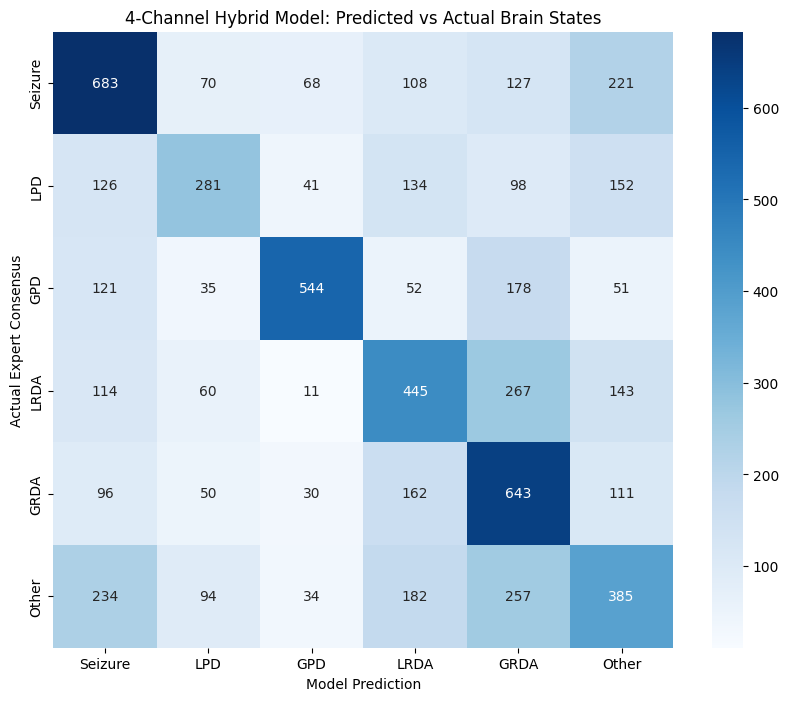

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Put the model in evaluation mode (turns off Dropout and BatchNorm updates)
model.eval()

all_preds = []
all_targets = []

print("Evaluating 4-Channel Hybrid Model on Validation Set...")

with torch.no_grad(): # No gradients needed for evaluation, saves memory and time
    for eeg, math, targets in val_loader:
        eeg, math = eeg.to(device), math.to(device)
        
        # Model outputs log probabilities
        log_preds = model(eeg, math)
        
        # Convert back to standard probabilities (0 to 1)
        preds = torch.exp(log_preds)
        
        # Move back to CPU for Scikit-Learn
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Convert probability distributions to hard predictions (Majority Vote)
pred_classes = np.argmax(all_preds, axis=1)
target_classes = np.argmax(all_targets, axis=1)

class_names = ['Seizure', 'LPD', 'GPD', 'LRDA', 'GRDA', 'Other']

# Print Metrics
acc = accuracy_score(target_classes, pred_classes)
print(f"\nOverall Accuracy (Majority Vote): {acc * 100:.2f}%\n")

print("--- Detailed Classification Report ---")
print(classification_report(target_classes, pred_classes, target_names=class_names, zero_division=0))

# Plot the Confusion Matrix
cm = confusion_matrix(target_classes, pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('4-Channel Hybrid Model: Predicted vs Actual Brain States')
plt.ylabel('Actual Expert Consensus')
plt.xlabel('Model Prediction')
plt.show()

Efficient Net

In [9]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

print("Starting Fast Spectrogram Extraction (50% Subset)...")
full_train_df = pd.read_csv('/kaggle/input/competitions/hms-harmful-brain-activity-classification/train.csv')

# Randomly sample exactly 50% of the dataset
train_df = full_train_df.sample(frac=0.5, random_state=42).reset_index(drop=True)
base_spec_path = '/kaggle/input/competitions/hms-harmful-brain-activity-classification/train_spectrograms/'

save_dir = '/kaggle/working/specs_npy/'
os.makedirs(save_dir, exist_ok=True)

# Save the subset CSV so the DataLoader can find it later
csv_save_path = '/kaggle/working/spectrogram_dataset_50.csv'
train_df.to_csv(csv_save_path, index=False)

# The magic of Spectrograms: We only need to process UNIQUE files
unique_specs = train_df['spectrogram_id'].unique()
print(f"Original rows: {len(train_df)} | Unique physical files to process: {len(unique_specs)}")

for spec_id in tqdm(unique_specs):
    file_path = f"{base_spec_path}{spec_id}.parquet"
    
    try:
        # Read the parquet file
        spec_data = pd.read_parquet(file_path)
        
        # Fill NaNs and drop the 'time' column to get just the pure frequency matrix
        spec_data = spec_data.fillna(0)
        spec_matrix = spec_data.drop(columns=['time']).values
        
        # Save as a lightning-fast .npy file
        np.save(f"{save_dir}{spec_id}.npy", spec_matrix)
        
    except Exception as e:
        continue

print(f"\nExtraction Complete! Saved to {save_dir}")

Starting Fast Spectrogram Extraction (50% Subset)...
Original rows: 53400 | Unique physical files to process: 9335


100%|██████████| 9335/9335 [08:00<00:00, 19.43it/s]


Extraction Complete! Saved to /kaggle/working/specs_npy/


In [10]:
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import time
import os

# --- 1. THE DATASET LOADER ---
class FastSpectrogramDataset(Dataset):
    def __init__(self, dataframe, base_path):
        self.df = dataframe.reset_index(drop=True)
        self.base_path = base_path
        self.target_cols = ['seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        spec_id = row['spectrogram_id']
        offset = row['spectrogram_label_offset_seconds']
        
        # Load the fast .npy file
        file_path = f"{self.base_path}{spec_id}.npy"
        spec_matrix = np.load(file_path)
        
        # Slice the 10-minute window (300 time steps). Each row is 2 seconds.
        start_idx = int(offset / 2.0)
        sliced_spec = spec_matrix[start_idx:start_idx+300].T # Transpose to (Freq, Time)
        
        # Safety padding if file is short
        if sliced_spec.shape[1] < 300:
            pad_width = 300 - sliced_spec.shape[1]
            sliced_spec = np.pad(sliced_spec, ((0, 0), (0, pad_width)), mode='constant')
            
        # Preprocessing: Log Transform (for visual contrast) and Normalize
        sliced_spec = np.log1p(sliced_spec)
        img_mean = np.mean(sliced_spec)
        img_std = np.std(sliced_spec) + 1e-6
        normalized_spec = (sliced_spec - img_mean) / img_std
        
        # Convert to 3-Channel Image for EfficientNet [3, 400, 300]
        image = np.zeros((3, normalized_spec.shape[0], normalized_spec.shape[1]), dtype=np.float32)
        image[0, :, :] = normalized_spec
        image[1, :, :] = normalized_spec
        image[2, :, :] = normalized_spec
        
        tensor_image = torch.tensor(image, dtype=torch.float32)
        
        # Targets (Soft Labels)
        votes = row[self.target_cols].values.astype(np.float32)
        target_probs = votes / np.sum(votes)
        
        return tensor_image, torch.tensor(target_probs, dtype=torch.float32)

# --- 2. THE VISION MODEL ---
class EEGEfficientNet(nn.Module):
    def __init__(self, num_classes=6):
        super(EEGEfficientNet, self).__init__()
        self.base_model = models.efficientnet_b0(weights='DEFAULT')
        in_features = self.base_model.classifier[1].in_features
        self.base_model.classifier[1] = nn.Linear(in_features, num_classes)
        self.log_softmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = self.base_model(x)
        return self.log_softmax(x)

# --- 3. SETUP & STRICT SPLITTING ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Setting up Pipeline on: {device}")

# Load the CSV we saved in Step 1
df = pd.read_csv('/kaggle/working/spectrogram_dataset_50.csv')

# Ensure we only use rows where the .npy file successfully extracted
npy_dir = '/kaggle/working/specs_npy/'
df = df[df['spectrogram_id'].apply(lambda x: os.path.exists(f"{npy_dir}{x}.npy"))]

# Strict 80/20 Train/Val Split to prevent Data Leakage
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = FastSpectrogramDataset(train_df, npy_dir)
val_dataset = FastSpectrogramDataset(val_df, npy_dir)

# Batch size 32 is safe for EfficientNet on T4 GPUs
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

model = EEGEfficientNet(num_classes=6).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) # Lower LR for Transfer Learning
criterion = nn.KLDivLoss(reduction='batchmean')

# --- 4. THE TRAINING LOOP ---
epochs = 5 # 5 Epochs is enough for a strong baseline
best_val_loss = float('inf')

print(f"\n🚀 Training on {len(train_dataset)} images | Validating on {len(val_dataset)} unseen images")

for epoch in range(epochs):
    start_time = time.time()
    
    # -- TRAIN PHASE --
    model.train()
    total_train_loss = 0
    for images, targets in train_loader:
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), targets)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * images.size(0)
        
    avg_train_loss = total_train_loss / len(train_dataset)
    
    # -- VALIDATION PHASE --
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for images, targets in val_loader:
            images, targets = images.to(device), targets.to(device)
            loss = criterion(model(images), targets)
            total_val_loss += loss.item() * images.size(0)
            
    avg_val_loss = total_val_loss / len(val_dataset)
    
    # Save best weights
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), '/kaggle/working/best_vision_model.pth')
        saved_flag = "--> [Best Model Saved!]"
    else:
        saved_flag = ""
        
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1:02d} | Time: {epoch_time:.0f}s | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} {saved_flag}")

Setting up Pipeline on: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:01<00:00, 13.8MB/s]



🚀 Training on 42720 images | Validating on 10680 unseen images
Epoch 01 | Time: 574s | Train Loss: 0.5817 | Val Loss: 0.3656 --> [Best Model Saved!]
Epoch 02 | Time: 573s | Train Loss: 0.3586 | Val Loss: 0.2832 --> [Best Model Saved!]
Epoch 03 | Time: 573s | Train Loss: 0.2733 | Val Loss: 0.2499 --> [Best Model Saved!]
Epoch 04 | Time: 574s | Train Loss: 0.2270 | Val Loss: 0.2301 --> [Best Model Saved!]
Epoch 05 | Time: 573s | Train Loss: 0.1932 | Val Loss: 0.2197 --> [Best Model Saved!]


Evaluating Vision Model on Validation Set...

Overall Accuracy (Majority Vote): 85.67%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

     Seizure       0.91      0.91      0.91      2092
         LPD       0.85      0.79      0.82      1491
         GPD       0.91      0.90      0.91      1662
        LRDA       0.83      0.84      0.84      1686
        GRDA       0.88      0.89      0.88      1851
       Other       0.76      0.80      0.78      1898

    accuracy                           0.86     10680
   macro avg       0.86      0.85      0.86     10680
weighted avg       0.86      0.86      0.86     10680



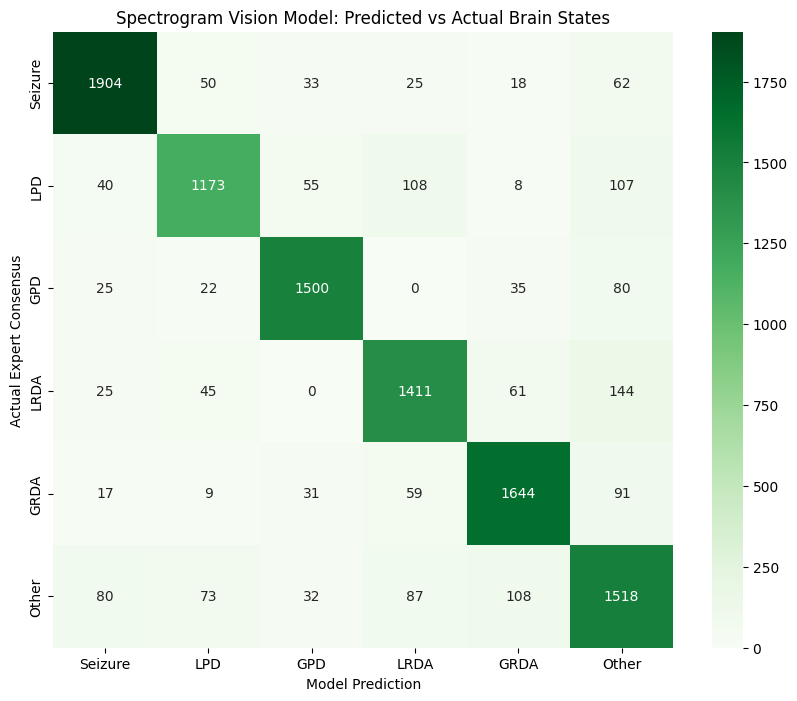

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# 1. Load the Best Model Weights
model.load_state_dict(torch.load('/kaggle/working/best_vision_model.pth'))
model.eval()

all_preds = []
all_targets = []

print("Evaluating Vision Model on Validation Set...")

with torch.no_grad(): # No gradients needed for evaluation
    for images, targets in val_loader:
        images = images.to(device)
        
        # Model outputs log probabilities
        log_preds = model(images)
        
        # Convert back to standard probabilities (0 to 1)
        preds = torch.exp(log_preds)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# 2. Convert to Hard Predictions
pred_classes = np.argmax(all_preds, axis=1)
target_classes = np.argmax(all_targets, axis=1)

class_names = ['Seizure', 'LPD', 'GPD', 'LRDA', 'GRDA', 'Other']

# 3. Print the Metrics
acc = accuracy_score(target_classes, pred_classes)
print(f"\nOverall Accuracy (Majority Vote): {acc * 100:.2f}%\n")

print("--- Detailed Classification Report ---")
print(classification_report(target_classes, pred_classes, target_names=class_names, zero_division=0))

# 4. Plot the Confusion Matrix
cm = confusion_matrix(target_classes, pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Spectrogram Vision Model: Predicted vs Actual Brain States')
plt.ylabel('Actual Expert Consensus')
plt.xlabel('Model Prediction')
plt.show()

1. Loading metadata and finding ideal samples...
2. Extracting raw signals and isolating 5-second center windows...
3. Crunching Non-Linearity Metrics (This takes a few seconds)...

--- RESULTS ---
BASELINE (Other) -> SampEn: 0.2537 | PermEn: 1.4535 | LLE: 0.0042
PATHOLOGY (GRDA) -> SampEn: 0.2300 | PermEn: 1.5030 | LLE: 0.0069


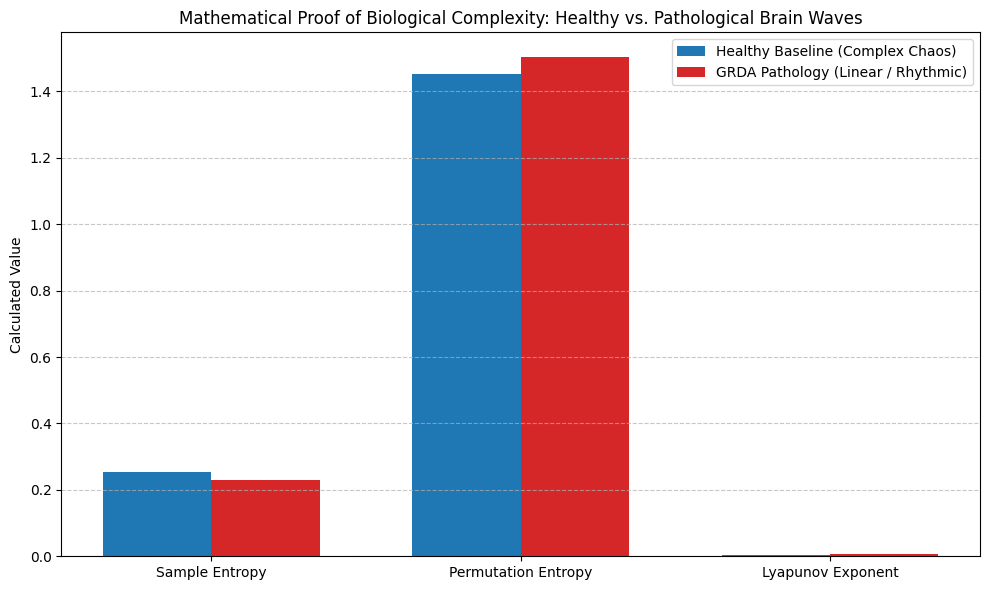

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
import antropy as ant
import nolds
import warnings

warnings.filterwarnings("ignore")

# 1. Bandpass Filter Setup
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return b, a

def apply_bandpass(data, lowcut, highcut, fs=200.0, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return lfilter(b, a, data)

print("1. Loading metadata and finding ideal samples...")
df = pd.read_csv('/kaggle/input/competitions/hms-harmful-brain-activity-classification/train.csv')
other_sample = df[df['other_vote'] >= 10].iloc[0]
grda_sample = df[df['grda_vote'] >= 10].iloc[0]

# 2. Extraction and Processing Function
def extract_and_prep(row):
    eeg_id = row['eeg_id']
    offset = row['eeg_label_offset_seconds']
    path = f"/kaggle/input/competitions/hms-harmful-brain-activity-classification/train_eegs/{eeg_id}.parquet"
    
    # Load and slice the 50-second window
    eeg_data = pd.read_parquet(path)
    start = int(offset * 200)
    end = start + 10000
    raw = np.nan_to_num(eeg_data['Fp1'].values[start:end])
    
    # Isolate the exact center 5 seconds for the math (Steps 4000 to 5000)
    raw_center = raw[4000:5000]
    
    # Apply Filters
    broad = apply_bandpass(raw_center, 0.5, 45.0)
    low = apply_bandpass(raw_center, 0.5, 12.0)
    
    # Normalize (Z-score)
    broad_norm = (broad - np.mean(broad)) / (np.std(broad) + 1e-6)
    low_norm = (low - np.mean(low)) / (np.std(low) + 1e-6)
    
    return broad_norm, low_norm

print("2. Extracting raw signals and isolating 5-second center windows...")
other_broad, other_low = extract_and_prep(other_sample)
grda_broad, grda_low = extract_and_prep(grda_sample)

# 3. Chaos Math Calculations
def calc_metrics(broad, low):
    sampen = ant.sample_entropy(low)
    permen = ant.perm_entropy(low, order=3, delay=1)
    lle = nolds.lyap_r(broad)
    return sampen, permen, lle

print("3. Crunching Non-Linearity Metrics (This takes a few seconds)...")
o_se, o_pe, o_lle = calc_metrics(other_broad, other_low)
g_se, g_pe, g_lle = calc_metrics(grda_broad, grda_low)

print("\n--- RESULTS ---")
print(f"BASELINE (Other) -> SampEn: {o_se:.4f} | PermEn: {o_pe:.4f} | LLE: {o_lle:.4f}")
print(f"PATHOLOGY (GRDA) -> SampEn: {g_se:.4f} | PermEn: {g_pe:.4f} | LLE: {g_lle:.4f}")

# 4. Plotting the Visual Proof
metrics = ['Sample Entropy', 'Permutation Entropy', 'Lyapunov Exponent']
other_vals = [o_se, o_pe, o_lle]
grda_vals = [g_se, g_pe, g_lle]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, other_vals, width, label='Healthy Baseline (Complex Chaos)', color='#1f77b4')
rects2 = ax.bar(x + width/2, grda_vals, width, label='GRDA Pathology (Linear / Rhythmic)', color='#d62728')

ax.set_ylabel('Calculated Value')
ax.set_title('Mathematical Proof of Biological Complexity: Healthy vs. Pathological Brain Waves')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
import antropy as ant
import nolds
import warnings

warnings.filterwarnings("ignore")

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return b, a

def apply_bandpass(data, lowcut, highcut, fs=200.0, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return lfilter(b, a, data)

print("1. Loading metadata...")
df = pd.read_csv('/kaggle/input/competitions/hms-harmful-brain-activity-classification/train.csv')
other_sample = df[df['other_vote'] >= 10].iloc[0]
grda_sample = df[df['grda_vote'] >= 10].iloc[0]

# Standard 16-channel clinical montage
channels = ['Fp1', 'F3', 'C3', 'P3', 'O1', 'Fp2', 'F4', 'C4', 'P4', 'O2', 'F7', 'T3', 'T5', 'F8', 'T4', 'T6']

def extract_car_and_prep(row):
    eeg_id = row['eeg_id']
    offset = row['eeg_label_offset_seconds']
    path = f"/kaggle/input/competitions/hms-harmful-brain-activity-classification/train_eegs/{eeg_id}.parquet"
    
    eeg_data = pd.read_parquet(path)
    start = int(offset * 200)
    end = start + 10000
    
    # Extract ALL 16 channels for the 50-second window
    all_signals = eeg_data[channels].values[start:end]
    all_signals = np.nan_to_num(all_signals)
    
    # --- APPLY CAR (Common Average Reference) ---
    # Calculate the average across all 16 channels at every time step
    global_average = np.mean(all_signals, axis=1)
    
    # Subtract the global noise from our target channel (Fp1 is index 0)
    fp1_clean = all_signals[:, 0] - global_average
    
    # Isolate the exact center 5 seconds (Steps 4000 to 5000)
    fp1_center = fp1_clean[4000:5000]
    
    # Apply Filters
    broad = apply_bandpass(fp1_center, 0.5, 45.0)
    low = apply_bandpass(fp1_center, 0.5, 12.0)
    
    # Normalize (Z-score)
    broad_norm = (broad - np.mean(broad)) / (np.std(broad) + 1e-6)
    low_norm = (low - np.mean(low)) / (np.std(low) + 1e-6)
    
    return broad_norm, low_norm

print("2. Extracting 16 channels, applying CAR, and isolating Fp1...")
other_broad, other_low = extract_car_and_prep(other_sample)
grda_broad, grda_low = extract_car_and_prep(grda_sample)

def calc_metrics(broad, low):
    sampen = ant.sample_entropy(low)
    permen = ant.perm_entropy(low, order=3, delay=1)
    lle = nolds.lyap_r(broad)
    return sampen, permen, lle

print("3. Crunching Non-Linearity Metrics on CAR-Cleaned Data...")
o_se, o_pe, o_lle = calc_metrics(other_broad, other_low)
g_se, g_pe, g_lle = calc_metrics(grda_broad, grda_low)

print("\n--- RESULTS AFTER CAR CLEANING ---")
print(f"BASELINE (Other) -> SampEn: {o_se:.4f} | PermEn: {o_pe:.4f} | LLE: {o_lle:.4f}")
print(f"PATHOLOGY (GRDA) -> SampEn: {g_se:.4f} | PermEn: {g_pe:.4f} | LLE: {g_lle:.4f}")

1. Loading metadata...
2. Extracting 16 channels, applying CAR, and isolating Fp1...
3. Crunching Non-Linearity Metrics on CAR-Cleaned Data...

--- RESULTS AFTER CAR CLEANING ---
BASELINE (Other) -> SampEn: 0.1868 | PermEn: 1.4349 | LLE: 0.0035
PATHOLOGY (GRDA) -> SampEn: 0.2152 | PermEn: 1.4592 | LLE: 0.0062


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
from scipy.stats import kurtosis
from sklearn.decomposition import FastICA
import antropy as ant
import nolds
import warnings

warnings.filterwarnings("ignore")

def butter_bandpass(lowcut, highcut, fs, order=4):
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return b, a
nyq = 0.5 * 200.0

def apply_bandpass(data, lowcut, highcut, fs=200.0, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return lfilter(b, a, data)

df = pd.read_csv('/kaggle/input/competitions/hms-harmful-brain-activity-classification/train.csv')
other_sample = df[df['other_vote'] >= 10].iloc[0]
grda_sample = df[df['grda_vote'] >= 10].iloc[0]

channels = ['Fp1', 'F3', 'C3', 'P3', 'O1', 'Fp2', 'F4', 'C4', 'P4', 'O2', 'F7', 'T3', 'T5', 'F8', 'T4', 'T6']

def extract_ica_and_prep(row):
    eeg_id = row['eeg_id']
    offset = row['eeg_label_offset_seconds']
    path = f"/kaggle/input/competitions/hms-harmful-brain-activity-classification/train_eegs/{eeg_id}.parquet"
    
    eeg_data = pd.read_parquet(path)
    
    # 1. Extract 60 seconds of data for ICA (12,000 points)
    start = int(offset * 200)
    end = start + 12000
    
    # Ensure we don't go out of bounds
    if end > len(eeg_data):
        end = len(eeg_data)
        start = end - 12000
        
    X = eeg_data[channels].values[start:end]
    X = np.nan_to_num(X)
    
    # 2. RUN FAST ICA
    # We ask it to find 16 independent sources
    ica = FastICA(n_components=16, random_state=42, max_iter=1000)
    components = ica.fit_transform(X) # Shape: [12000, 16]
    
    # 3. AUTOMATED ARTIFACT REMOVAL
    # Eye blinks and muscle twitches have high Kurtosis (they are very spiky).
    # We find the component with the highest kurtosis and zero it out.
    kurts = kurtosis(components, axis=0)
    blink_idx = np.argmax(kurts)
    components[:, blink_idx] = 0 
    
    # 4. RECONSTRUCT THE CLEAN EEG
    X_clean = ica.inverse_transform(components)
    
    # 5. ISOLATE TARGET (Fp1 is index 0) AND SLICE 5-SECOND CENTER
    # The middle 5 seconds of our 60-second window is roughly points 5000 to 6000
    fp1_clean = X_clean[:, 0]
    fp1_center = fp1_clean[5000:6000]
    
    # Apply Filters
    broad = apply_bandpass(fp1_center, 0.5, 45.0)
    low = apply_bandpass(fp1_center, 0.5, 12.0)
    
    # Normalize (Z-score)
    broad_norm = (broad - np.mean(broad)) / (np.std(broad) + 1e-6)
    low_norm = (low - np.mean(low)) / (np.std(low) + 1e-6)
    
    return broad_norm, low_norm

print("Running 60-Second ICA & Automated Artifact Removal...")
other_broad, other_low = extract_ica_and_prep(other_sample)
grda_broad, grda_low = extract_ica_and_prep(grda_sample)

def calc_metrics(broad, low):
    sampen = ant.sample_entropy(low)
    permen = ant.perm_entropy(low, order=3, delay=1)
    lle = nolds.lyap_r(broad)
    return sampen, permen, lle

print("Crunching Non-Linearity Metrics on ICA-Cleaned Data...")
o_se, o_pe, o_lle = calc_metrics(other_broad, other_low)
g_se, g_pe, g_lle = calc_metrics(grda_broad, grda_low)

print("\n--- RESULTS AFTER 60-SECOND ICA CLEANING ---")
print(f"BASELINE (Other) -> SampEn: {o_se:.4f} | PermEn: {o_pe:.4f} | LLE: {o_lle:.4f}")
print(f"PATHOLOGY (GRDA) -> SampEn: {g_se:.4f} | PermEn: {g_pe:.4f} | LLE: {g_lle:.4f}")

Running 60-Second ICA & Automated Artifact Removal...
Crunching Non-Linearity Metrics on ICA-Cleaned Data...

--- RESULTS AFTER 60-SECOND ICA CLEANING ---
BASELINE (Other) -> SampEn: 0.2567 | PermEn: 1.5091 | LLE: 0.0037
PATHOLOGY (GRDA) -> SampEn: 0.2960 | PermEn: 1.4279 | LLE: -0.0041


Loading metadata...
Extracting signals and simulating temporal state transition...


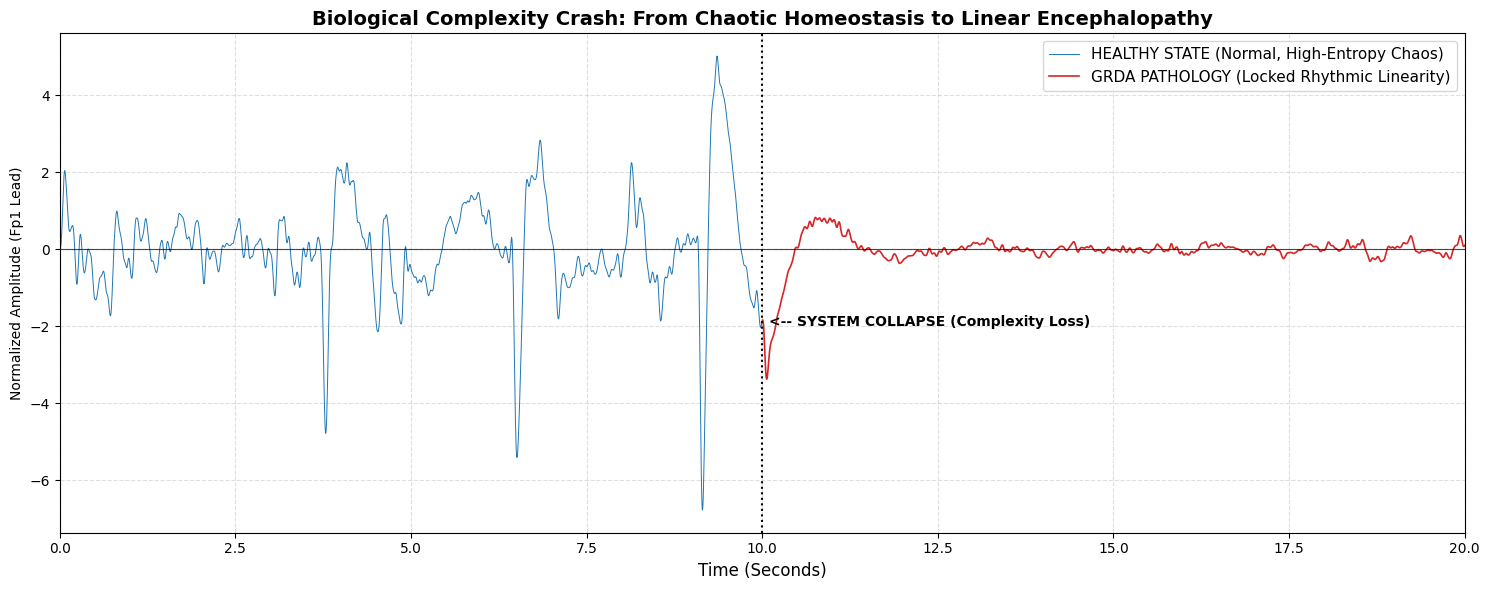

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
import os
import warnings

warnings.filterwarnings("ignore")

# --- 1. SETUP & FILTER (Wider band needed for chaos visualization) ---
# We need a wider low-band (0.5 - 12 Hz) to preserve the complexity
# in the healthy state while still showing the delta-rhythm in GRDA.
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return b, a

def apply_bandpass(data, lowcut, highcut, fs=200.0, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return lfilter(b, a, data)

print("Loading metadata...")
df = pd.read_csv('/kaggle/input/competitions/hms-harmful-brain-activity-classification/train.csv')

# Find samples (ensure the files exist on disk before proceeding)
def get_verified_verified_sample(criteria):
    potential_samples = df[criteria]
    for _, row in potential_samples.iterrows():
        eeg_id = row['eeg_id']
        path = f"/kaggle/input/competitions/hms-harmful-brain-activity-classification/train_eegs/{eeg_id}.parquet"
        if os.path.exists(path):
            return row
    raise FileNotFoundError("Could not find verified .parquet file for criteria.")

# --- 2. THE CHRONOLOGICAL EXTRACTION ---
# We must find two unique samples and physically concatenate them
# to simulate the temporal collapse of chaos into pathology.

def prep_signals_for_condensed_plot():
    other_sample = get_verified_verified_sample(df['other_vote'] >= 10)
    grda_sample = get_verified_verified_sample(df['grda_vote'] >= 10)
    
    # Process "Other" (Healthy Chaos) - 10 Seconds
    path_other = f"/kaggle/input/competitions/hms-harmful-brain-activity-classification/train_eegs/{other_sample['eeg_id']}.parquet"
    start_row_other = int(other_sample['eeg_label_offset_seconds'] * 200)
    # Extract 10 seconds of raw signal to capture sustained chaos (2000 points)
    raw_other = pd.read_parquet(path_other)['Fp1'].values[start_row_other:start_row_other+2000]
    
    # Process "GRDA" (Pathological Linearity) - 10 Seconds
    path_grda = f"/kaggle/input/competitions/hms-harmful-brain-activity-classification/train_eegs/{grda_sample['eeg_id']}.parquet"
    start_row_grda = int(grda_sample['eeg_label_offset_seconds'] * 200)
    # Extract 10 seconds of GRDA pathology
    raw_grda = pd.read_parquet(path_grda)['Fp1'].values[start_row_grda:start_row_grda+2000]
    
    # --- PHYSICAL CONCATENATION (Healthy -> Pathology) ---
    raw_concat = np.concatenate([raw_other, raw_grda])
    raw_concat = np.nan_to_num(raw_concat)
    
    # Filter the concatenated wave in a wider low-band (0.5 Hz - 12.0 Hz)
    # to preserve high-frequency complexity in the healthy section.
    signal_low_band = apply_bandpass(raw_concat, 0.5, 12.0)
    
    # Standardize variance across the entire 20-second wave
    global_norm = (signal_low_band - np.mean(signal_low_band)) / (np.std(signal_low_band) + 1e-6)
    
    return global_norm

print("Extracting signals and simulating temporal state transition...")
transition_signal = prep_signals_for_condensed_plot()

# --- 3. THE CONDENSED PLOT ---
# Create time axis for the full 20 seconds (4000 points)
time_axis = np.linspace(0, 20, 4000)

plt.figure(figsize=(15, 6))

# Use contrasting colors to show the transition points. 
# We explicitly plot the two segments back-to-back.

# Plot Healthy Segment (0-10s) in Blue
plt.plot(time_axis[0:2000], transition_signal[0:2000], color='#1f77b4', linewidth=0.7, label='HEALTHY STATE (Normal, High-Entropy Chaos)')

# Plot Pathological Segment (10-20s) in Red
plt.plot(time_axis[2000:], transition_signal[2000:], color='#d62728', linewidth=1.2, label='GRDA PATHOLOGY (Locked Rhythmic Linearity)')

# Formatting for a powerful presentation slide
plt.title('Biological Complexity Crash: From Chaotic Homeostasis to Linear Encephalopathy', fontsize=14, fontweight='bold')
plt.ylabel('Normalized Amplitude (Fp1 Lead)')
plt.xlabel('Time (Seconds)', fontsize=12)

# Grid and reference lines
plt.grid(True, linestyle='--', alpha=0.4)
plt.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.7)

# Explicitly label the transition point at 10 seconds
plt.axvline(10, color='black', linewidth=1.5, linestyle=':', alpha=1.0)
plt.text(10.1, -2.0, '<-- SYSTEM COLLAPSE (Complexity Loss)', fontsize=10, fontweight='bold', color='black')

plt.xlim(0, 20)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()